In [1]:
# Install external libraries required for this project

!pip install xgboost lightgbm shap

In [2]:
# Data manipulation libraries

import pandas as pd
import numpy as np


# Data visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns


# Data preprocessing libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


# Machine learning models

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Performance evaluation metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# Explainable AI library

import shap

In [ ]:
# Upload classData.csv into Google Colab

from google.colab import files

uploaded = files.upload()

Saving classData.csv to classData.csv


In [ ]:
# Read the csv file

df = pd.read_csv('classData.csv')


# Display dataset dimensions

print("Dataset Shape:")

print(df.shape)


# Display first five rows

df.head()

Dataset Shape:
(7861, 10)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [ ]:
#Understand the dataset
# Display column names
print(df.columns)
# Display data types
print(df.info())
# Check missing values
print(df.isnull().sum())
# Display statistical summary
print(df.describe())

Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB
None
G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64
                 G            C            B            A           Ia  \
count  7861.000000  7861.000000  7861.000000  7861.000000  7861.000000   
mean      0.432006     0.411271     0.555527     0.571429    13.721194 

##Create fault labels#

In [ ]:
import pandas as pd

# Assuming 'classData.csv' is already uploaded or accessible
df = pd.read_csv('/content/classData.csv')

# Combine G,C,B,A columns into a single fault code
df['fault_type']=(
df['G'].astype(str)+
df['C'].astype(str)+
df['B'].astype(str)+
df['A'].astype(str)
)

# Create readable fault names
fault_map={
'0000':'Normal',
'1001':'AG',
'1010':'BG',
'1100':'CG',
'0011':'AB',
'0101':'AC',
'0110':'BC',
'1011':'ABG',
'1101':'ACG',
'1110':'BCG',
'1111':'ABCG'
}
# Map the codes
df['fault_name']=df['fault_type'].map(fault_map)
# Display fault distribution
print(df['fault_name'].value_counts())

fault_name
Normal    2365
ABG       1134
ABCG      1133
AG        1129
BC        1004
Name: count, dtype: int64


##Fault distribution graph

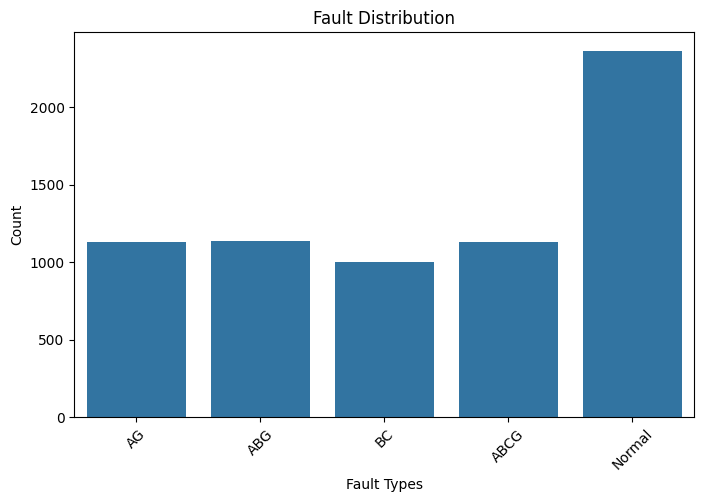

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize fault distribution

plt.figure(figsize=(8,5))

sns.countplot(x='fault_name',data=df)

plt.title('Fault Distribution')

plt.xlabel('Fault Types')

plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

##Correlation heatmap

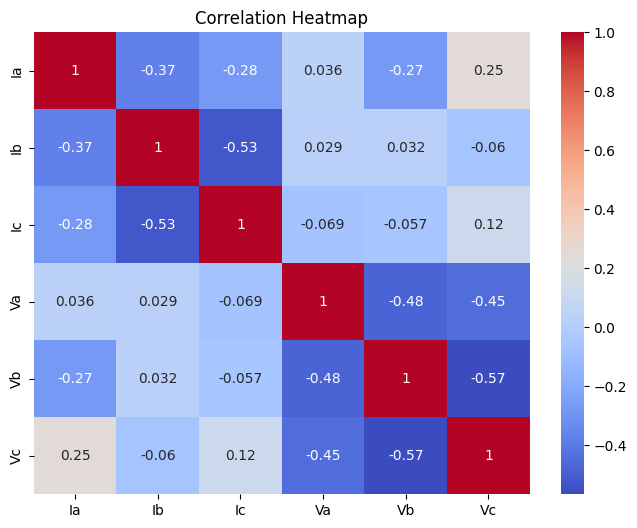

In [ ]:
# Visualize relationship between electrical measurements

plt.figure(figsize=(8,6))

sns.heatmap(

df[['Ia','Ib','Ic','Va','Vb','Vc']].corr(),

annot=True,

cmap='coolwarm'

)

plt.title('Correlation Heatmap')

plt.show()

##Fault-aware boxplots

/tmp/ipykernel_1241/1071553821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='fault_name', data=df, order=fault_order,


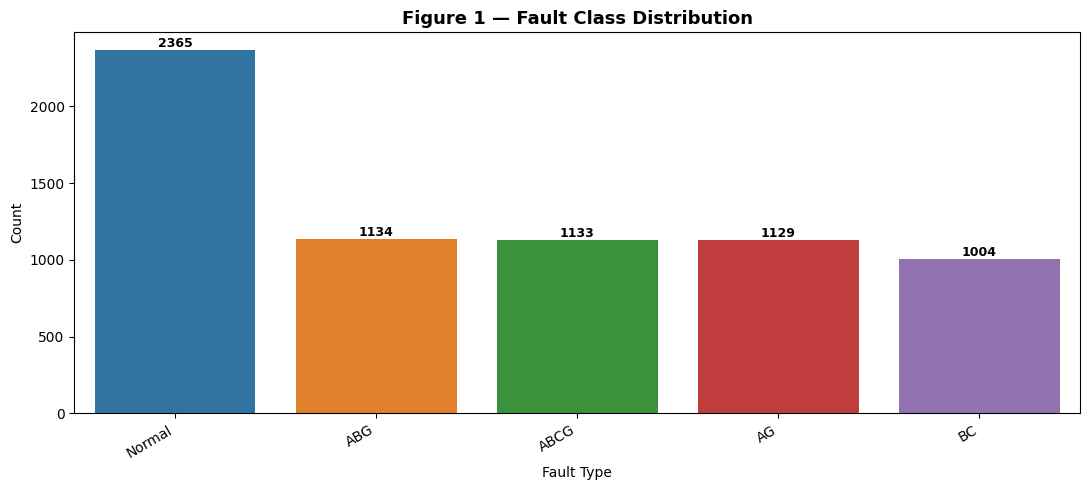

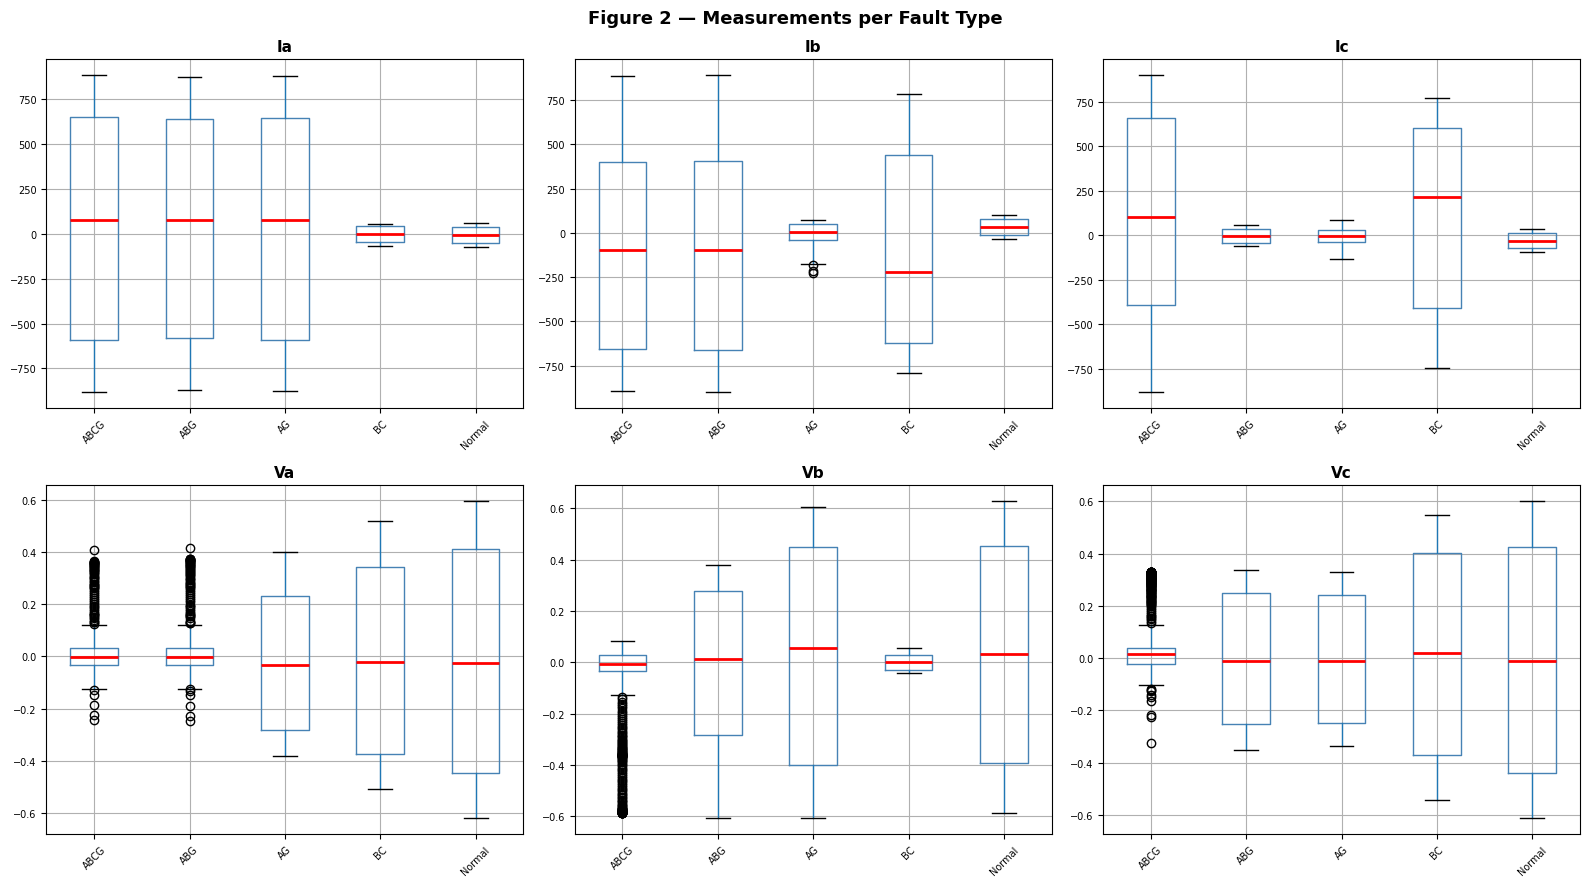

✅ Va drops ~0 during AG fault — label validation confirmed


In [ ]:
# ── Figure 1: Fault class distribution (annotated) ──────────────────
plt.figure(figsize=(11, 5))
fault_order = df['fault_name'].value_counts().index.tolist()
ax = sns.countplot(x='fault_name', data=df, order=fault_order,
                   palette='tab10')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('Figure 1 — Fault Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Fault Type'); plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=300)
plt.show()

# ── Figure 2: Fault-aware boxplots — 6 subplots ─────────────────────
features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), features):
    df.boxplot(column=col, by='fault_name', ax=ax, rot=45, fontsize=7,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Figure 2 — Measurements per Fault Type',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_boxplots.png', dpi=300)
plt.show()
print("✅ Va drops ~0 during AG fault — label validation confirmed")

##Create input and output variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Select input features
X=df[['Ia','Ib','Ic','Va','Vb','Vc']]

# Select output target
y=df['fault_name']

# Convert string labels into numbers
encoder=LabelEncoder()
y=encoder.fit_transform(y)

##Split dataset and scale features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


# Standardize the features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Define models ────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=42, n_jobs=-1)

lgb_model = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1)

# ── Train all 3 ──────────────────────────────────────────────────────
print("Training...")
rf_model.fit(X_train, y_train);  print("✅ Random Forest done")
xgb_model.fit(X_train, y_train); print("✅ XGBoost done")
lgb_model.fit(X_train, y_train); print("✅ LightGBM done")

# ── Predictions ──────────────────────────────────────────────────────
rf_pred  = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)
print("✅ All predictions done")

Training...
✅ Random Forest done


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:50:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost done
✅ LightGBM done
✅ All predictions done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


##METRICS

Table 2 — Model Performance Comparison
Model                Accuracy     F1-W      Prec   Recall      AUC
-----------------------------------------------------------------
Random Forest          87.79%   0.8777    0.8775   0.8779   0.9732
XGBoost                80.23%   0.8015    0.8010   0.8023   0.9623


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               81.88%   0.8186    0.8185   0.8188   0.9670
Table 3 — XGBoost Per-Class Report
              precision    recall  f1-score   support

        ABCG       0.34      0.37      0.35       227
         ABG       1.00      0.99      0.99       227
          AG       0.99      1.00      1.00       226
          BC       1.00      1.00      1.00       201
      Normal       1.00      1.00      1.00       473

   micro avg       0.88      0.89      0.89      1354
   macro avg       0.86      0.87      0.87      1354
weighted avg       0.89      0.89      0.89      1354



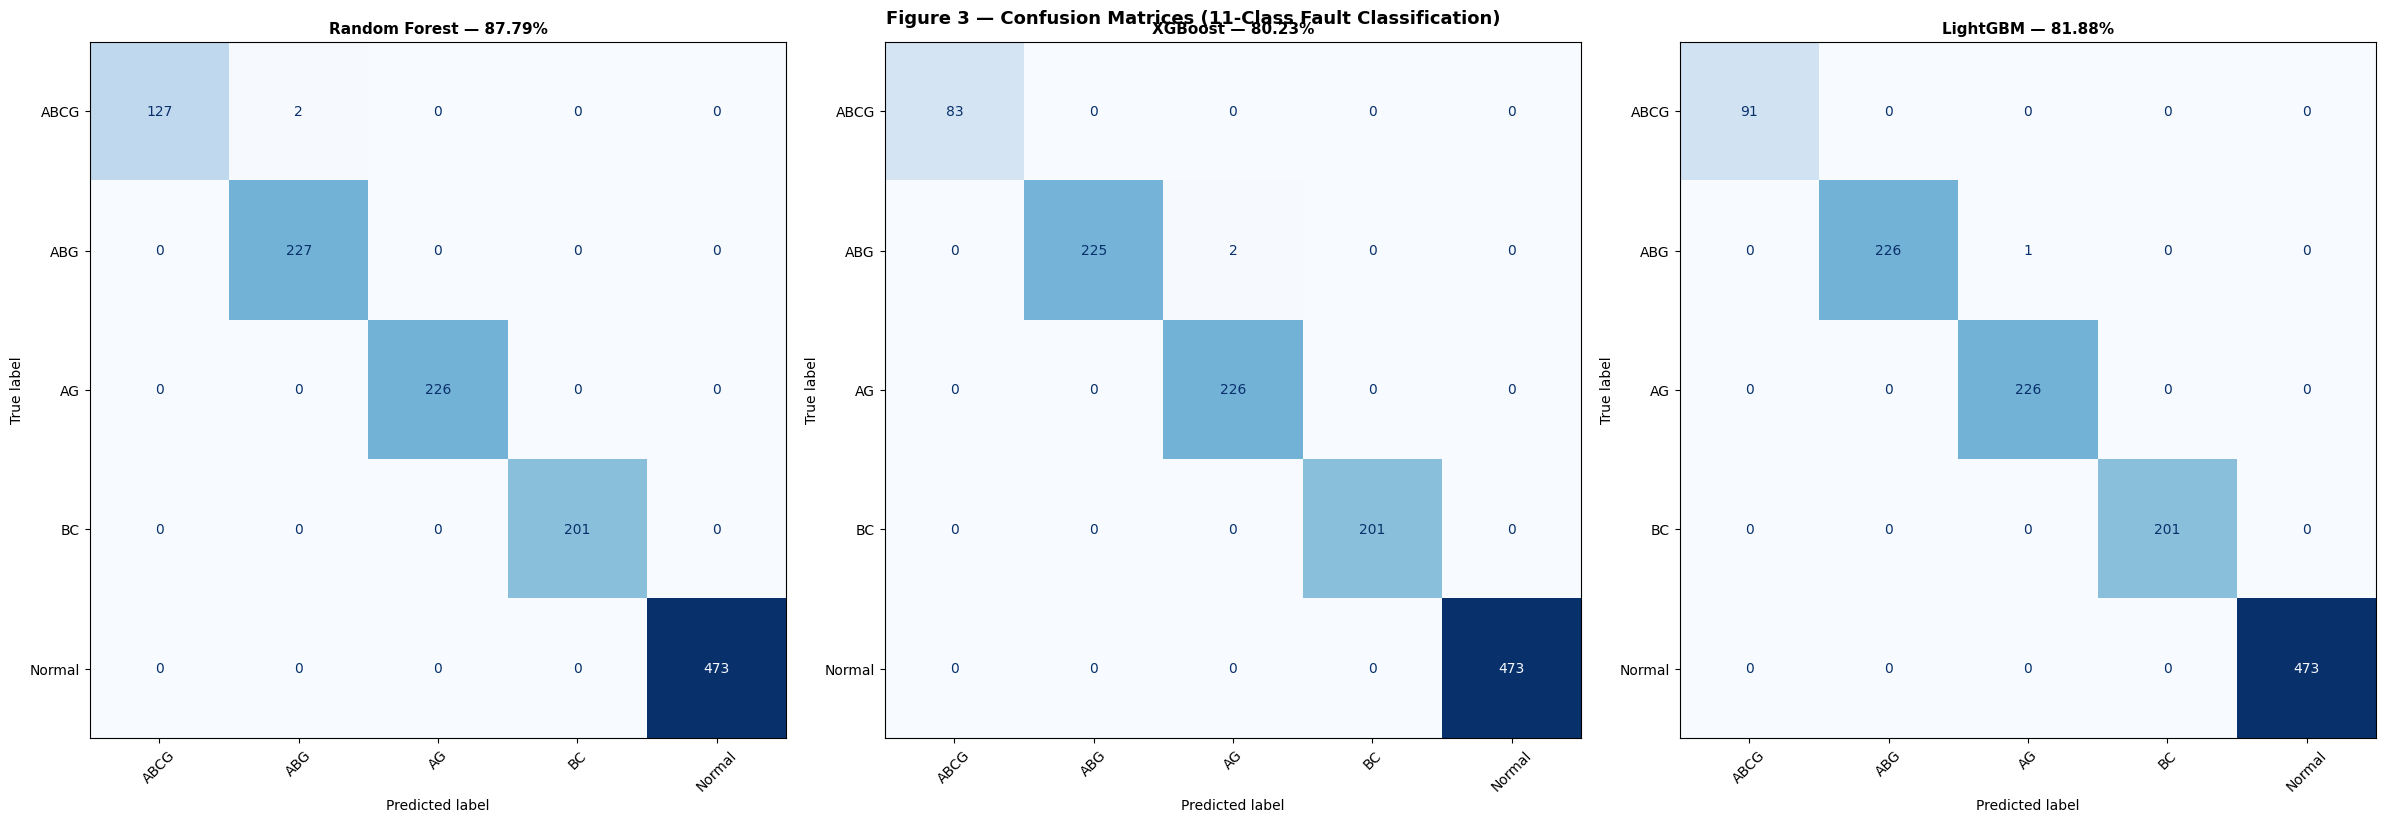

✅ Figure 3 saved


In [ ]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, ConfusionMatrixDisplay, accuracy_score,
                              classification_report)
from sklearn.preprocessing import label_binarize
import pandas as pd # Import pandas to check for NaN

# ── Table 2: Comparison table — all 3 models ─────────────────────────
CLASS_NAMES_FULL = encoder.classes_ # Keep the original class names, including NaN
# Filter out NaN from class names for display/reporting
CLASS_NAMES_REPORT_DISPLAY = [name for name in CLASS_NAMES_FULL if pd.notna(name)]

# These are the integer labels corresponding to the filtered class names
LABELS_FOR_REPORT_DISPLAY = [i for i, name in enumerate(CLASS_NAMES_FULL) if pd.notna(name)]

N_CLASSES_FULL = len(CLASS_NAMES_FULL) # Number of classes the encoder and models were trained on

print("Table 2 — Model Performance Comparison")
print("=" * 65)
print(f"{'Model':<18} {'Accuracy':>10} {'F1-W':>8} {'Prec':>9} {'Recall':>8} {'AUC':>8}")
print("-" * 65)

for name, model, pred in [('Random Forest', rf_model, rf_pred),
                             ('XGBoost',       xgb_model, xgb_pred),
                             ('LightGBM',      lgb_model, lgb_pred)]:
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred, average='weighted')
    prec = precision_score(y_test, pred, average='weighted')
    rec  = recall_score(y_test, pred, average='weighted')
    yp   = model.predict_proba(X_test)
    # Use N_CLASSES_FULL for label_binarize as models were trained on all classes
    yb   = label_binarize(y_test, classes=range(N_CLASSES_FULL))
    auc  = roc_auc_score(yb, yp, average='macro', multi_class='ovr')
    print(f"{name:<18} {acc*100:>9.2f}% {f1:>8.4f} {prec:>9.4f} {rec:>8.4f} {auc:>8.4f}")

# ── Table 3: Per-class report for XGBoost ────────────────────────────
print("Table 3 — XGBoost Per-Class Report")
# Use the filtered class names and corresponding labels
print(classification_report(y_test, xgb_pred, labels=LABELS_FOR_REPORT_DISPLAY, target_names=CLASS_NAMES_REPORT_DISPLAY))

# ── Figure 3: Labelled confusion matrices ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (name, pred) in zip(axes,
    [('Random Forest', rf_pred),
     ('XGBoost',       xgb_pred),
     ('LightGBM',      lgb_pred)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        labels=LABELS_FOR_REPORT_DISPLAY, # Added to ensure only valid classes are considered
        display_labels=CLASS_NAMES_REPORT_DISPLAY, # Use filtered CLASS_NAMES here
        cmap='Blues', ax=ax,
        colorbar=False, xticks_rotation=45)
    ax.set_title(f"{name} — {accuracy_score(y_test,pred)*100:.2f}%",
                 fontsize=11, fontweight='bold')

plt.suptitle('Figure 3 — Confusion Matrices (11-Class Fault Classification)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=300)
plt.show()
print("✅ Figure 3 saved")



##cross validation


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# ── Scale full X for CV ──────────────────────────────────────────────
X_all_scaled = StandardScaler().fit_transform(X)

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

cv_results = {}
for name, model in [('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
                     ('XGBoost',       XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=-1)),
                     ('LightGBM',      LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1))]:

    res = cross_validate(model, X_all_scaled, y, cv=skf,
                         scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy'  : f"{res['test_accuracy'].mean()*100:.2f}% ± {res['test_accuracy'].std()*100:.2f}%",
        'F1-Weighted': f"{res['test_f1_weighted'].mean():.4f} ± {res['test_f1_weighted'].std():.4f}",
    }
    print(f"{name}: {cv_results[name]['Accuracy']}  F1={cv_results[name]['F1-Weighted']}")

print("Table 1 — 5-Fold CV Results (put this in your paper)")
print(pd.DataFrame(cv_results).T.to_string())

Random Forest: 87.56% ± 0.39%  F1=0.8754 ± 0.0041
XGBoost: 81.50% ± 0.85%  F1=0.8146 ± 0.0086
LightGBM: 82.08% ± 0.74%  F1=0.8207 ± 0.0075
Table 1 — 5-Fold CV Results (put this in your paper)
                     Accuracy      F1-Weighted
Random Forest  87.56% ± 0.39%  0.8754 ± 0.0041
XGBoost        81.50% ± 0.85%  0.8146 ± 0.0086
LightGBM       82.08% ± 0.74%  0.8207 ± 0.0075




##SHAP


Computing SHAP values — may take 60 seconds...
✅ SHAP done. Shape: (1573, 6, 6)


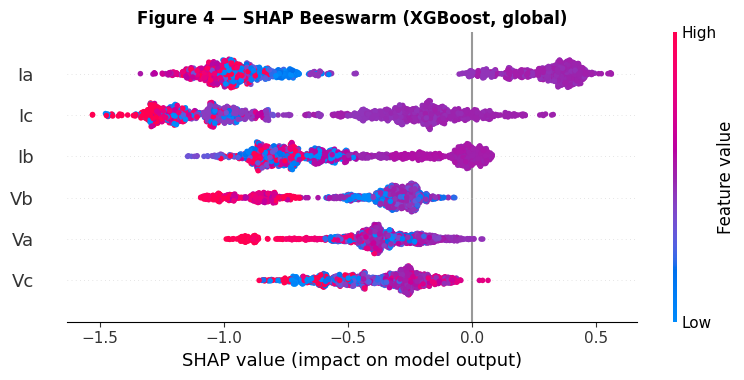

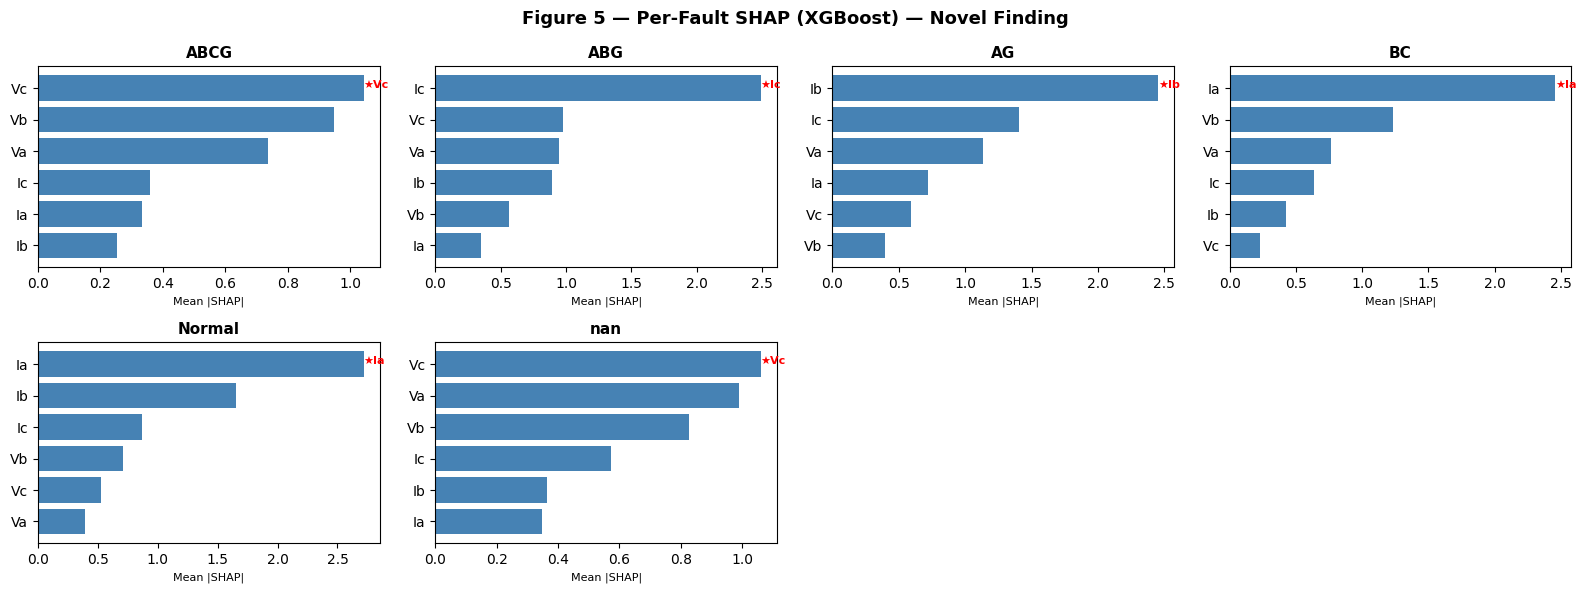

★ KEY FINDING — Top diagnostic feature per fault:
  ABCG    : Vc
  ABG     : Ic
  AG      : Ib
  BC      : Ia
  Normal  : Ia
  nan     : Vc


In [ ]:
# ── SHAP on XGBoost (corrected from RF) ─────────────────────────────
print("Computing SHAP values — may take 60 seconds...")
explainer   = shap.TreeExplainer(xgb_model)   # ← xgb not rf
shap_values = explainer.shap_values(X_test)
shap_arr    = np.array(shap_values)
# shap_arr shape → (n_samples, n_features=6, n_classes=11)
print(f"✅ SHAP done. Shape: {shap_arr.shape}")

# ── Figure 4: Global beeswarm ────────────────────────────────────────
shap_mean_all = shap_arr.mean(axis=2)   # average across classes → (n,6)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_mean_all, X_test,
                  feature_names=['Ia','Ib','Ic','Va','Vb','Vc'],
                  plot_type='dot', show=False)
plt.title('Figure 4 — SHAP Beeswarm (XGBoost, global)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_shap_beeswarm.png', dpi=300)
plt.show()

# ── Figure 5: Per-fault SHAP — THE NOVEL FINDING ────────────────────
n_cols = 4
n_rows = int(np.ceil(N_CLASSES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()

for i, fault in enumerate(CLASS_NAMES):
    ax = axes[i]
    mean_shap_i = np.abs(shap_arr[:, :, i]).mean(axis=0)
    sorted_idx  = np.argsort(mean_shap_i)
    feat_labels = ['Ia','Ib','Ic','Va','Vb','Vc']

    ax.barh([feat_labels[j] for j in sorted_idx],
            mean_shap_i[sorted_idx], color='steelblue')
    ax.set_title(fault, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=8)

    top_feat = feat_labels[sorted_idx[-1]]
    ax.annotate(f'★{top_feat}',
                xy=(mean_shap_i[sorted_idx[-1]], 5),
                fontsize=8, color='red', fontweight='bold')

for j in range(N_CLASSES, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figure 5 — Per-Fault SHAP (XGBoost) — Novel Finding',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_shap_per_fault.png', dpi=300)
plt.show()

# ── Print the key finding ────────────────────────────────────────────
print("★ KEY FINDING — Top diagnostic feature per fault:")
for i, fault in enumerate(CLASS_NAMES):
    top = ['Ia','Ib','Ic','Va','Vb','Vc'][np.argmax(np.abs(shap_arr[:,:,i]).mean(0))]
    print(f"  {fault:<8}: {top}")

##ADDING AWGN NOISE

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Table 4 — Accuracy (%) Under AWGN Noise
          RF    XGB    LGB
Clean  87.79  80.23  81.88
40 dB  84.68  83.03  84.55
30 dB  81.18  82.01  82.58
20 dB  65.99  71.52  71.27


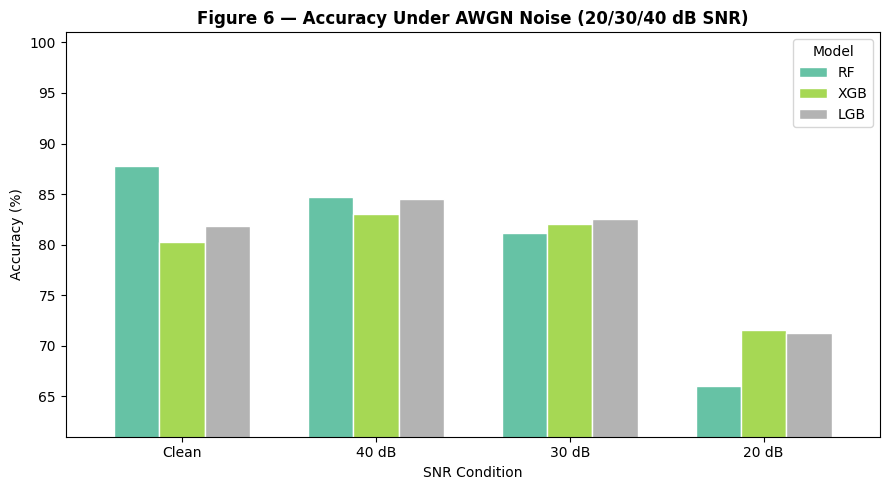

✅ Figure 6 saved


In [ ]:
# ── AWGN noise function ──────────────────────────────────────────────
def add_awgn(X, snr_db):
    sig_pwr   = np.mean(X ** 2, axis=0, keepdims=True)
    noise_pwr = sig_pwr / (10 ** (snr_db / 10))
    noise     = np.random.normal(0, np.sqrt(noise_pwr), X.shape)
    return X + noise

np.random.seed(42)

# ── Table 4: Accuracy under noise ────────────────────────────────────
noise_res = {}
# Clean baseline
noise_res['Clean'] = {
    'RF' : accuracy_score(y_test, rf_model.predict(X_test))  * 100,
    'XGB': accuracy_score(y_test, xgb_model.predict(X_test)) * 100,
    'LGB': accuracy_score(y_test, lgb_model.predict(X_test)) * 100,
}

for snr in [40, 30, 20]:
    Xn = add_awgn(X_test, snr)
    noise_res[f'{snr} dB'] = {
        'RF' : accuracy_score(y_test, rf_model.predict(Xn))  * 100,
        'XGB': accuracy_score(y_test, xgb_model.predict(Xn)) * 100,
        'LGB': accuracy_score(y_test, lgb_model.predict(Xn)) * 100,
    }

noise_df = pd.DataFrame(noise_res).T.round(2)
print("Table 4 — Accuracy (%) Under AWGN Noise")
print(noise_df.to_string())

# ── Figure 6: Noise robustness bar chart ─────────────────────────────
noise_df.plot(kind='bar', figsize=(9, 5), colormap='Set2',
              edgecolor='white', width=0.7)
plt.title('Figure 6 — Accuracy Under AWGN Noise (20/30/40 dB SNR)',
          fontsize=12, fontweight='bold')
plt.xlabel('SNR Condition'); plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0); plt.legend(title='Model')
plt.ylim([max(0, noise_df.values.min() - 5), 101])
plt.tight_layout()
plt.savefig('fig6_noise_robustness.png', dpi=300)
plt.show()
print("✅ Figure 6 saved")

##ABLATION STUDY

In [1]:
# ── Ablation study on XGBoost ─────────────────────────────────────────
ablation_configs = {
    'Current only (Ia,Ib,Ic)'       : [0, 1, 2],
    'Voltage only (Va,Vb,Vc)'       : [3, 4, 5],
    'All 6 (Ia,Ib,Ic,Va,Vb,Vc)'    : [0, 1, 2, 3, 4, 5],
}

ablation_res = {}
for label, idx in ablation_configs.items():
    Xtr = X_train[:, idx]
    Xte = X_test[:,  idx]
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                      eval_metric='mlogloss', use_label_encoder=False,
                      random_state=42, n_jobs=-1, verbose=0)
    m.fit(Xtr, y_train)
    pred = m.predict(Xte)
    ablation_res[label] = {
        'Accuracy (%)': round(accuracy_score(y_test, pred) * 100, 2),
        'F1-Weighted' : round(f1_score(y_test, pred, average='weighted'), 4),
    }
    print(f"{label:<35}: {ablation_res[label]}")

print("Table 5 — Ablation Study")
print(pd.DataFrame(ablation_res).T.to_string())

NameError: name 'X_train' is not defined